# Deep Q-Learning - 月球着陆器
在本作业中，你将训练一个智能体，使其在月球表面的着陆垫上安全着陆月球着陆器。
# 大纲
- [1 - 导入包 <img align="Right" src="./images/lunar_lander.gif" width = 60% >](#1)
- [2 - 超参数](#2)
- [3 - 月球着陆器环境](#3)
  - [3.1 动作空间](#3.1)
  - [3.2 观测空间](#3.2)
  - [3.3 奖励](#3.3)
  - [3.4 回合终止条件](#3.4)
- [4 - 加载环境](#4)
- [5 - 与Gym环境交互](#5)
    - [5.1 探索环境动态](#5.1)
- [6 - 深度Q学习](#6)
  - [6.1 目标网络](#6.1)
    - [练习1](#ex01)
  - [6.2 经验回放](#6.2)
- [7 - 带经验回放的深度Q学习算法](#7)
  - [练习2](#ex02)
- [8 - 更新网络权重](#8)
- [9 - 训练智能体](#9)
- [10 - 观看训练好的智能体运行](#10)
- [11 - 恭喜！](#11)
- [12 - 参考文献](#12)


<a name="1"></a>
## 1 - 导入包
我们将使用以下包：
- `numpy`是Python中用于科学计算的包。
- `deque`将作为我们记忆缓冲区的数据结构。
- `namedtuple`将用于存储经验元组。
- `gym`工具包是一组环境，可用于测试强化学习算法。
- `PIL.Image`和`pyvirtualdisplay`是渲染月球着陆器环境所必需的。
- 我们将使用`tensorflow.keras`框架中的几个模块来构建深度学习模型。
- `utils`是一个包含本作业辅助函数的模块。你无需修改此文件中的代码。

运行下面的代码块以导入所有必要的包。

In [1]:
import warnings
warnings.filterwarnings('ignore')
import time
from collections import deque, namedtuple

import gymnasium as gym
import numpy as np
import PIL.Image
import tensorflow as tf
import utils

from pyvirtualdisplay.display import Display
from keras import Sequential
from keras.layers import Dense, Input
from keras.losses import MeanSquaredError
MSE = MeanSquaredError()
from keras.optimizers import Adam

In [2]:
# 设置一个虚拟显示器来渲染月球着陆器环境。
import os
os.environ["PATH"] += ":/usr/local/opt/X11/bin"
display = Display(visible=False, size=(840, 480))
display.start()

# 为TensorFlow设置随机种子
tf.random.set_seed(utils.SEED)

<a name="2"></a>
## 2 - 超参数
运行下面的单元格以设置超参数。

In [3]:
MEMORY_SIZE = 100_000     # 内存缓冲区大小
GAMMA = 0.995            # 折扣因子
ALPHA = 1e-3              # 学习率
NUM_STEPS_FOR_UPDATE = 4  # 每4个时间步执行一次学习更新

<a name="3"></a>
## 3 - 月球着陆器环境
在本笔记本中，我们将使用[OpenAI的Gym库](https://www.gymlibrary.ml/)。Gym库为强化学习提供了各种各样的环境。简单来说，一个环境代表一个有待解决的问题或任务。在本笔记本中，我们将尝试使用强化学习来解决月球着陆器环境问题。
月球着陆器环境的目标是让月球着陆器安全降落在月球表面的着陆垫上。着陆垫由两根旗杆标识，其坐标始终为`(0,0)`，但着陆器也可以在着陆垫之外着陆。着陆器从环境顶部中心开始，其质心受到随机初始力作用，且拥有无限燃料。如果你获得`200`分，则认为该环境问题已解决。 

<br>
<br>
<figure>
  <img src = "images/lunar_lander.gif" width = 40%>
      <figcaption style = "text-align: center; font-style: italic">Fig 1. Lunar Lander Environment.</figcaption>
</figure>



<a name="3.1"></a>
### 3.1 动作空间
智能体有四个离散的可用动作：
* 不做任何操作。
* 点燃右侧发动机。
* 点燃主发动机。
* 点燃左侧发动机。
每个动作都有一个对应的数值：

```python
Do nothing = 0
Fire right engine = 1
Fire main engine = 2
Fire left engine = 3
```

<a name="3.2"></a>
### 3.2 观测空间
智能体的观测空间由一个包含8个变量的状态向量组成：
* 其$(x, y)$坐标。着陆平台始终位于坐标$(0, 0)$处。
* 其线速度$(\dot x, \dot y)$。
* 其角度$\theta$。
* 其角速度$\dot \theta$。
* 两个布尔值$l$和$r$，分别表示每条腿是否与地面接触。

<a name="3.3"></a>
### 3.3 奖励
月球着陆器环境具有以下奖励系统：
* 在着陆平台上着陆并静止，大约可得100 - 140分。
* 如果着陆器靠近着陆平台，有额外的奖励；如果着陆器远离着陆平台，有额外的惩罚。 
* 如果着陆器坠毁，则得 - 100分。
* 如果着陆器静止，则得 + 100分。
* 每条与地面接触的支腿得 + 10分。
* 每启动主发动机扣 - 0.3分。
* 每启动侧发动机扣 - 0.03分。

<a name="3.4"></a>
### 3.4 回合终止
如果满足以下条件，一个回合结束（即环境进入终止状态）：
* 月球着陆器坠毁（即如果月球着陆器的主体与月球表面接触）。
* 着陆器的x坐标大于1。
你可以查看 [Open AI Gym文档](https://www.gymlibrary.ml/environments/box2d/lunar_lander/) 以获取环境的完整描述。 

<a name="4"></a>
## 4 - 加载环境
我们首先使用`.make()`方法从`gym`库中加载`LunarLander - v3`环境。`LunarLander - v3`是月球着陆器环境的最新版本，你可以在[Open AI Gym文档](https://www.gymlibrary.ml/environments/box2d/lunar_lander/#version-history)中查看其版本历史。

In [4]:
env = gym.make('LunarLander-v3', render_mode="rgb_array")

一旦加载了环境，我们就使用`.reset()`方法将环境重置为初始状态。   
着陆器从环境的顶部中心开始，我们可以使用`.render()`方法渲染环境的第一帧。

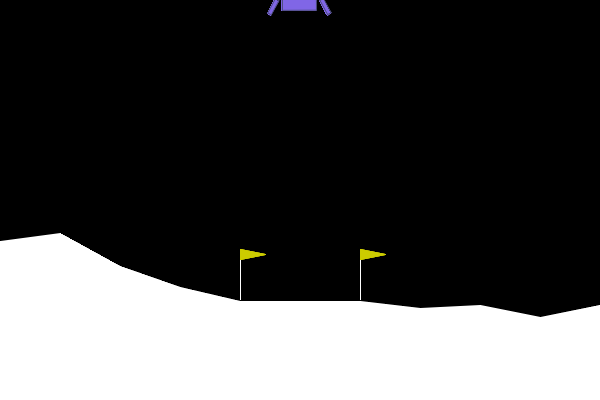

In [5]:
env.reset()
#PIL.Image.fromarray(env.render(mode='rgb_array'))
PIL.Image.fromarray(env.render())

为了后续构建我们的神经网络，我们需要知道状态向量的大小以及有效动作的数量。我们可以分别通过使用`.observation_space.shape`和`action_space.n`方法从环境中获取这些信息。

In [6]:
state_size = env.observation_space.shape
num_actions = env.action_space.n

print('State Shape:', state_size)
print('Number of actions:', num_actions)

State Shape: (8,)
Number of actions: 4


<a name="5"></a>
## 5 - 与Gym环境交互
Gym库实现了标准的“智能体 - 环境循环”形式体系：

<br>
<center>
<video src = "./videos/rl_formalism.m4v" width="840" height="480" controls autoplay loop poster="./images/rl_formalism.png"> </video>
<figcaption style = "text-align:center; font-style:italic">图2. 智能体 - 环境循环形式体系。</figcaption>
</center>
<br>

在标准的“智能体 - 环境循环”形式体系中，智能体以离散时间步$t = 0, 1, 2, \ldots$与环境进行交互。在每个时间步$t$，智能体根据其对环境状态$S_t$的观察，使用策略$\pi$来选择一个动作$A_t$。智能体获得一个数值奖励$R_t$，并在接下来的时间步转移到一个新状态$S_{t + 1}$。

<a name="5.1"></a>
### 5.1 探索环境动态
在Open AI的Gym环境中，我们使用`.step()`方法来运行环境动态的单个时间步。在我们使用的`gym`版本中，`.step()`方法接受一个动作并返回四个值：   

* `observation`（**对象**）：一个特定于环境的对象，表示你对环境的观察。在月球着陆器环境中，这对应于一个NumPy数组，其中包含如[3.2 观测空间](#3.2) 节所述的着陆器的位置和速度。
* `reward`（**浮点数**）：采取给定动作后返回的奖励量。在月球着陆器环境中，这对应于如[3.3 奖励](#3.3) 节所述的`numpy.float64`类型的浮点数。
* `done`（**布尔值**）：当`done`为`True`时，表示该情节已终止，是时候重置环境了。新版Gymnasium返回的是两个值：
    * `terminated`（**布尔值**）：表示任务本身的终止条件（如着陆成功、坠毁）。
    * `truncated`（**布尔值**）：表示外部截断条件（如时间步超过上限、强行终止）。
    * 需通过`done = terminated or truncated`还原旧版本的"情节终止"逻辑。
* `info`（**字典**）：对调试有用的诊断信息。在本笔记本中我们不会使用这个变量，但为了完整性在此展示。

要开始一个episode，我们需要将环境重置为初始状态。我们通过使用`.reset()`方法来实现这一点。

In [7]:
# Reset the environment and get the initial state.
initial_state = env.reset()

环境重置后，智能体可以通过使用 `.step()` 方法在环境中开始采取行动。请注意，智能体每个时间步只能采取一个行动。
在下面的代码单元格中，你可以选择不同的行动，并观察返回值如何根据所采取的行动而变化。请记住，在这个环境中，智能体有四个离散的行动可供选择，我们在代码中通过使用它们相应的数值来指定这些行动：

```python
Do nothing = 0
Fire right engine = 1
Fire main engine = 2
Fire left engine = 3
```

In [8]:
# Select an action
action = 0

# Run a single time step of the environment's dynamics with the given action.
# next_state, reward, done, info = env.step(action)
# 按 Gymnasium 常见的返回值结构解包
next_state, reward, terminated, truncated, info = env.step(action)
# 可以把 terminated 和 truncated 合并到一个 done 逻辑（类似旧版）
done = terminated or truncated  

with np.printoptions(formatter={'float': '{:.3f}'.format}):
    print("Initial State:", initial_state)
    print("Action:", action)
    print("Next State:", next_state)
    print("Reward Received:", reward)
    print("Episode Terminated:", done)
    print("Info:", info)

Initial State: (array([0.002, 1.411, 0.170, -0.015, -0.002, -0.039, 0.000, 0.000],
      dtype=float32), {})
Action: 0
Next State: [0.003 1.410 0.170 -0.040 -0.004 -0.038 0.000 0.000]
Reward Received: -0.48740520866039105
Episode Terminated: False
Info: {}


在实践中，当我们训练智能体时，会使用一个循环，以便智能体在一个episode中能够连续采取多个动作。

<a name="6"></a>
## 6 - 深度Q-Learning
在状态空间和动作空间均为离散的情况下，我们可以通过使用贝尔曼方程迭代地估计动作价值函数：

$$
Q_{i+1}(s,a) = R + \gamma \max_{a'}Q_i(s',a')
$$

这种迭代方法在 $i\to\infty$ 时收敛到最优动作价值函数 $Q^*(s,a)$。这意味着智能体只需逐步探索状态 - 动作空间，并持续更新 $Q(s,a)$ 的估计值，直到它收敛到最优动作价值函数 $Q^*(s,a)$。然而，在状态空间是连续的情况下，实际上不可能探索整个状态 - 动作空间。因此，这也使得实际上不可能逐步估计 $Q(s,a)$ 直到它收敛到 $Q^*(s,a)$。

在深度$Q$-Learning中，我们通过使用神经网络来估计动作价值函数 $Q(s,a)\approx Q^*(s,a)$ 来解决这个问题。我们将这个神经网络称为$Q$-Network，并且可以通过在每次迭代时调整其权重，以最小化贝尔曼方程中的均方误差来对其进行训练。

不幸的是，事实证明在强化学习中使用神经网络来估计动作价值函数非常不稳定。幸运的是，有几种技术可以用来避免不稳定性。这些技术包括使用**目标网络**和**经验回放**。我们将在以下部分探讨这两种技术。

<a name="6.1"></a>
### 6.1 目标网络
我们可以通过在每次迭代时调整 $Q$ 网络的权重，来最小化贝尔曼方程中的均方误差，从而对其进行训练。其中，目标值由下式给出：
$$
y = R + \gamma \max_{a'}Q(s',a';w)
$$
其中 $w$ 是 $Q$ 网络的权重。这意味着我们在每次迭代时调整权重 $w$，以最小化以下误差：
$$
\overbrace{\underbrace{R + \gamma \max_{a'}Q(s',a'; w)}_{\text{y 目标}} - Q(s,a;w)}^{\text{误差}}
$$
请注意，这会产生一个问题，因为 $y$ 作为目标，每次迭代时都在变化。目标不断变动会导致振荡和不稳定。为避免这种情况，我们可以创建一个单独的神经网络来生成 $y$ 目标。我们将这个单独的神经网络称为**目标 $\hat Q$ 网络**，它将具有与原始 $Q$ 网络相同的架构。通过使用目标 $\hat Q$ 网络，上述误差变为：
$$
\overbrace{\underbrace{R + \gamma \max_{a'}\hat{Q}(s',a'; w^-)}_{\text{y 目标}} - Q(s,a;w)}^{\text{误差}}
$$
其中 $w^-$ 和 $w$ 分别是目标 $\hat Q$ 网络和 $Q$ 网络的权重。
在实践中，我们将使用以下算法：每 $C$ 个时间步，我们将使用 $\hat Q$ 网络生成 $y$ 目标，并使用 $Q$ 网络的权重更新目标 $\hat Q$ 网络的权重。我们将使用**软更新**来更新目标 $\hat Q$ 网络的权重 $w^-$。这意味着我们将使用以下规则更新权重 $w^-$：
$$
w^-\leftarrow \tau w + (1 - \tau) w^-
$$
其中 $\tau\ll 1$。通过使用软更新，我们确保目标值 $y$ 缓慢变化，这大大提高了我们学习算法的稳定性。

<a name="ex01"></a>
### 练习1
在本练习中，你将创建 $Q$ 网络和目标 $\hat Q$ 网络，并设置优化器。请记住，深度 $Q$ 网络（DQN）是一种神经网络，用于近似动作价值函数 $Q(s,a)\approx Q^*(s,a)$。它通过学习如何将状态映射到 $Q$ 值来实现这一点。

为了解决月球着陆器环境问题，我们将采用具有以下架构的 DQN：
* 一个“输入”层，以“状态大小”作为输入。
* 一个具有 64 个单元和“relu”激活函数的“密集”层。
* 一个具有 64 个单元和“relu”激活函数的“密集”层。
* 一个具有“动作数量”个单元和“线性”激活函数的“密集”层。这将是我们网络的输出层。

在下面的代码单元格中，你应该使用上述描述的模型架构创建 $Q$ 网络和目标 $\hat Q$ 网络。请记住，$Q$ 网络和目标 $\hat Q$ 网络具有相同的架构。

最后，你应该将“Adam”设置为优化器，学习率等于“ALPHA”。回想一下，“ALPHA”在[超参数](#2)部分中定义。我们应该注意，对于本练习，你应该使用已经导入的包：
```python
from tensorflow.keras.layers import Dense, Input
from tensorflow.keras.optimizers import Adam
```

In [9]:
# UNQ_C1
# GRADED CELL

# Create the Q-Network
q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),                      
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'),
    ### END CODE HERE ### 
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    ### START CODE HERE ### 
    Input(shape=state_size),                       
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'),
    ### END CODE HERE ###
    ])

### START CODE HERE ### 
optimizer = Adam(learning_rate=ALPHA)
### END CODE HERE ###



In [10]:
# UNIT TEST
from public_tests import *

test_network(q_network)
test_network(target_q_network)
test_optimizer(optimizer, ALPHA) 

All tests passed!
All tests passed!
All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
```python
# Create the Q-Network
q_network = Sequential([
    Input(shape=state_size),                      
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'),
    ])

# Create the target Q^-Network
target_q_network = Sequential([
    Input(shape=state_size),                       
    Dense(units=64, activation='relu'),            
    Dense(units=64, activation='relu'),            
    Dense(units=num_actions, activation='linear'), 
    ])

optimizer = Adam(learning_rate=ALPHA)                                  
``` 

<a name="6.2"></a>
### 6.2 经验回放
当智能体与环境进行交互时，智能体所经历的状态、行动和奖励本质上是顺序发生的。如果智能体试图从这些连续的经验中学习，由于它们之间存在很强的相关性，可能会遇到问题。为避免这种情况，我们采用一种称为**经验回放**的技术，为训练智能体生成不相关的经验。经验回放包括将智能体的经验（即智能体接收到的状态、行动和奖励）存储在记忆缓冲区中，然后从缓冲区中随机采样一个`mini-batch`的经验来进行学习。随着智能体与环境的交互，经验元组$(S_t, A_t, R_t, S_{t+1})$将在每个时间步添加到记忆缓冲区中。   

为方便起见，我们将经验存储为具名元组。 

In [11]:
# Store experiences as named tuples
experience = namedtuple("Experience", field_names=["state", "action", "reward", "next_state", "done"])

通过使用经验回放，我们避免了有问题的相关性、振荡和不稳定性。此外，经验回放还允许智能体在多次权重更新中潜在地使用相同的经验，这提高了数据效率。

<a name="7"></a>
## 7 - 带经验回放的深度Q学习算法   

既然我们已经了解了将要使用的所有技术，那么就可以将它们整合起来，得出带经验回放的深度Q学习算法。
<br>
<br>
<figure>
  <img src = "images/deep_q_algorithm.png" width = 90% style = "border: thin silver solid; padding: 0px">
      <figcaption style = "text-align: center; font-style: italic">图3. 带经验回放的深度Q-Learning。</figcaption>
</figure>

<a name="ex02"></a>
### 练习2
在本练习中，你将实现上述图3中概述算法的第***12***行，并且还要计算 $y$ 目标值与 $Q(s,a)$ 值之间的损失。在下面的代码单元格中，通过将 $y$ 目标值设为以下等式来完成 `compute_loss` 函数：
$$
\begin{equation}
    y_j =
    \begin{cases}
      R_j & \text{如果情节在步骤 } j + 1 \text{ 终止}\\
      R_j + \gamma \max_{a'}\hat{Q}(s_{j+1},a') & \text{否则}\\
    \end{cases}       
\end{equation}
$$
这里有几点需要注意：
* `compute_loss` 函数接收一小批经验元组。这批经验元组会被解包，以提取出 `states`（状态）、`actions`（动作）、`rewards`（奖励）、`next_states`（下一个状态）和 `done_vals`（结束值）。你应该记住，这些变量是 *TensorFlow 张量*，其大小将取决于这批数据的大小。例如，如果这批数据的大小为 `64`，那么 `rewards` 和 `done_vals` 都将是具有 `64` 个元素的 TensorFlow 张量。
* 当变量是具有多个元素的张量时，使用 `if/else` 语句来设置 $y$ 目标值将不起作用。不过，请注意，你可以使用 `done_vals` 在一行代码中实现上述操作。要做到这一点，回想一下，`done` 变量是一个布尔变量，当情节在步骤 $j + 1$ 终止时，其值为 `True`，否则为 `False`。考虑到布尔值 `True` 的数值为 `1`，布尔值 `False` 的数值为 `0`，你可以使用因子 `(1 - done_vals)` 在一行代码中实现上述操作。这里有个提示：注意当 `done_vals` 为 `True` 时，`(1 - done_vals)` 的值为 `0`，当 `done_vals` 为 `False` 时，其值为 `1`。 
最后，通过计算 `y_targets` 和 `q_values` 之间的均方误差（`MSE`）来计算损失。要计算均方误差，你应该使用已经导入的 `MSE` 包：
```python
from tensorflow.keras.losses import MSE
```

In [12]:
# UNQ_C2
# GRADED FUNCTION: calculate_loss

def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """
    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    ### START CODE HERE ### 
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))
    ### END CODE HERE ###
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
        
    # Compute the loss
    ### START CODE HERE ### 
    loss = MSE(y_targets, q_values) 
    ### END CODE HERE ### 
    
    return loss

In [13]:
# UNIT TEST    
test_compute_loss(compute_loss)

All tests passed!


<details>
  <summary><font size="3" color="darkgreen"><b>Click for hints</b></font></summary>
    
```python
def compute_loss(experiences, gamma, q_network, target_q_network):
    """ 
    Calculates the loss.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
      q_network: (tf.keras.Sequential) Keras model for predicting the q_values
      target_q_network: (tf.keras.Sequential) Karas model for predicting the targets
          
    Returns:
      loss: (TensorFlow Tensor(shape=(0,), dtype=int32)) the Mean-Squared Error between
            the y targets and the Q(s,a) values.
    """

    
    # Unpack the mini-batch of experience tuples
    states, actions, rewards, next_states, done_vals = experiences
    
    # Compute max Q^(s,a)
    max_qsa = tf.reduce_max(target_q_network(next_states), axis=-1)
    
    # Set y = R if episode terminates, otherwise set y = R + γ max Q^(s,a).
    y_targets = rewards + (gamma * max_qsa * (1 - done_vals))
    
    # Get the q_values
    q_values = q_network(states)
    q_values = tf.gather_nd(q_values, tf.stack([tf.range(q_values.shape[0]),
                                                tf.cast(actions, tf.int32)], axis=1))
    
    # Calculate the loss
    loss = MSE(y_targets, q_values)
    
    return loss

``` 
    

<a name="8"></a>
## 8 - 更新网络权重
我们将使用下面的`agent_learn`函数来实现[图3](#7)中概述算法的第***12 - 14***行。`agent_learn`函数将使用自定义训练循环来更新$Q$网络和目标$\hat Q$网络的权重。由于我们使用的是自定义训练循环，所以需要通过`tf.GradientTape`实例来获取梯度，然后调用`optimizer.apply_gradients()`来更新我们$Q$网络的权重。请注意，我们还使用了`@tf.function`装饰器来提高性能。如果没有这个装饰器，我们的训练时间将翻倍。如果你想了解更多关于如何使用`@tf.function`提高性能的内容，可以查看[TensorFlow文档](https://www.tensorflow.org/guide/function)。   

该函数的最后一行使用[软更新](#6.1)来更新目标$\hat Q$网络的权重。如果你想知道这在代码中是如何实现的，我们建议你查看`utils`模块中的`utils.update_target_network`函数。 

In [14]:
@tf.function
def agent_learn(experiences, gamma):
    """
    Updates the weights of the Q networks.
    
    Args:
      experiences: (tuple) tuple of ["state", "action", "reward", "next_state", "done"] namedtuples
      gamma: (float) The discount factor.
    
    """
    
    # Calculate the loss
    with tf.GradientTape() as tape:
        loss = compute_loss(experiences, gamma, q_network, target_q_network)

    # Get the gradients of the loss with respect to the weights.
    gradients = tape.gradient(loss, q_network.trainable_variables)
    
    # Update the weights of the q_network.
    optimizer.apply_gradients(zip(gradients, q_network.trainable_variables))

    # update the weights of target q_network,软更新
    utils.update_target_network(q_network, target_q_network)

<a name="9"></a>
## 9 - 训练智能体
我们现在准备训练智能体以解决月球着陆器环境问题。在下面的代码单元中，我们将逐行实现[图3](#7)中的算法（请注意，为方便参考，我们在下方也包含了相同的算法，这样你就无需在笔记本中上下滚动查看）：
* **第1行**：我们使用容量为$N =$ `MEMORY_SIZE` 初始化 `memory_buffer`。注意，我们使用 `deque` 作为 `memory_buffer` 的数据结构。

* **第2行**：由于我们已经在[练习1](#ex01)中初始化了 `q_network`，所以跳过这一行。

* **第3行**：我们通过将 `target_q_network` 的权重设置为与 `q_network` 的权重相等来初始化 `target_q_network`。

* **第4行**：我们开始外层循环。注意，我们设置了$M =$ `num_episodes = 2000`。这个数字是合理的，因为使用本笔记本的默认参数，智能体应该能够在少于 `2000` 个 episodes 内解决月球着陆器环境问题。

* **第5行**：我们使用 `.reset()` 方法将环境重置为初始状态并获取初始状态。


* **第6行**：我们开始内层循环。注意，我们设置了$T =$ `max_num_timesteps = 1000`。这意味着如果一个 episode 在 `1000` 个时间步后仍未结束，它将自动终止。


* **第7行**：智能体观察当前的 `state`，并使用 $\epsilon$-贪婪策略选择一个 `action`。我们的智能体最初使用 $\epsilon =$ `epsilon = 1` 的值，这产生的 $\epsilon$-贪婪策略等同于等概率随机策略。这意味着在训练开始时，智能体将不管观察到的 `state` 而采取随机行动。随着训练的进行，我们将使用给定的 $\epsilon$ 衰减率逐渐将 $\epsilon$ 的值缓慢降低到最小值。我们希望这个最小值接近零，因为 $\epsilon = 0$ 时产生的 $\epsilon$-贪婪策略等同于贪婪策略。这意味着在训练接近尾声时，智能体将倾向于选择它认为（基于其过去的经验）能使 $Q(s,a)$ 最大化的 `action`。我们将最小 $\epsilon$ 值设置为 `0.01` 而不是精确的0，因为我们始终希望在训练期间保留一点探索性。如果你想知道这在代码中是如何实现的，我们建议你查看 `utils` 模块中的 `utils.get_action` 函数。


* **第8行**：我们使用 `.step()` 方法在环境中采取给定的 `action`，并获取 `reward` 和 `next_state`。


* **第9行**：我们将 `experience(state, action, reward, next_state, done)` 元组存储在 `memory_buffer` 中。注意，我们还存储了 `done` 变量，以便我们可以跟踪一个 episode 何时终止。这使我们能够在[练习2](#ex02)中设置 $y$ 目标。


* **第10行**：我们检查执行学习更新的条件是否满足。我们通过使用自定义的 `utils.check_update_conditions` 函数来完成此操作。此函数检查是否已经过了 $C =$ `NUM_STEPS_FOR_UPDATE = 4` 个时间步，以及我们的 `memory_buffer` 是否有足够的经验元组来填充一个`mini-batch`。例如，如果`mini-batch`大小为 `64`，那么我们的 `memory_buffer` 至少应该有 `64` 个经验元组才能满足后一个条件。如果条件满足，那么 `utils.check_update_conditions` 函数将返回 `True`，否则返回 `False`。


* **第11 - 14行**：如果 `update` 变量为 `True`，那么我们执行学习更新。学习更新包括从 `memory_buffer` 中随机采样一个`mini-batch`的经验元组，设置 $y$ 目标，执行梯度下降，并更新网络的权重。我们将使用在[第8节](#8)中定义的 `agent_learn` 函数来执行后三个操作。


* **第15行**：在内层循环的每次迭代结束时，我们将 `next_state` 设置为我们的新 `state`，以便循环可以从这个新状态重新开始。此外，我们检查 episode 是否已达到终止状态（即我们检查 `done = True`）。如果已达到终止状态，则跳出内层循环。


* **第16行**：在外层循环的每次迭代结束时，我们更新 $\epsilon$ 的值，并检查环境是否已被解决。如果智能体在过去 `100` 个 episodes 中平均获得 `200` 分，我们认为环境已被解决。如果环境尚未解决，我们继续外层循环并开始新的 episode。


最后，我们想指出，我们添加了一些额外的变量来跟踪智能体在每个 episode 中获得的总分数。这将帮助我们确定智能体是否解决了环境问题，并且还能让我们了解智能体在训练期间的表现。我们还使用 `time` 模块来测量训练所需的时间。    

<br>
<br>
<figure>
  <img src = "images/deep_q_algorithm.png" width = 90% style = "border: thin silver solid; padding: 0px">
      <figcaption style = "text-align: center; font-style: italic">图4. 带经验回放的深度Q-Learning。</figcaption>
</figure>
<br>   

**注意**：使用此笔记本的默认参数，以下代码单元运行需要10到15分钟。 

In [15]:

start = time.time()

num_episodes = 20
max_num_timesteps = 1000

total_point_history = []

num_p_av = 100    # 用于求平均的总分数数量
epsilon = 1.0     # ε贪心策略的初始ε值

# 创建一个容量为N的记忆缓冲区D
memory_buffer = deque(maxlen=MEMORY_SIZE)

# 将目标网络权重设置为与Q网络权重相等
target_q_network.set_weights(q_network.get_weights())

for i in range(num_episodes):
    
    # 将环境重置为初始状态并获取初始状态
    state, _ = env.reset()
    state = np.array(state)
    total_points = 0
    
    for t in range(max_num_timesteps):
        
        # 使用ε-贪心策略从当前状态S中选择一个动作A
        state_qn = np.expand_dims(state, axis=0) # 状态的形状必须与Q网络匹配
        q_values = q_network(state_qn)
        action = utils.get_action(q_values, epsilon)
        
        # 执行动作A，获得奖励R和下一个状态S'
        #next_state, reward, done, _ = env.step(action)
        next_state, reward, terminated, truncated, _ = env.step(action)
        # 可以把 terminated 和 truncated 合并到一个 done 逻辑（类似旧版）
        done = terminated or truncated  
        
        # 将经验元组（S，A，R，S'）存储在记忆缓冲区中。
        # 为了方便起见，我们也存储完成变量。
        memory_buffer.append(experience(state, action, reward, next_state, done))
        
        # 仅每隔 NUM_STEPS_FOR_UPDATE 个时间步更新一次网络。
        update = utils.check_update_conditions(t, NUM_STEPS_FOR_UPDATE, memory_buffer)
        
        if update:
            # 从经验回放池D中随机采样一个mini-batch的经验元组（S，A，R，S'），不会重复采样
            experiences = utils.get_experiences(memory_buffer)
            
            # 设置y目标，执行梯度下降步骤，并更新网络权重。
            agent_learn(experiences, GAMMA)
        
        state = next_state.copy()
        total_points += reward
        
        if done:
            break
            
    total_point_history.append(total_points)
    av_latest_points = np.mean(total_point_history[-num_p_av:])
    
    # Update the ε value
    epsilon = utils.get_new_eps(epsilon)

    print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}", end="")

    if (i+1) % num_p_av == 0:
        print(f"\rEpisode {i+1} | Total point average of the last {num_p_av} episodes: {av_latest_points:.2f}")

    # 如果在最后100 episode里平均获得240分，我们将认为环境已解决。
    if av_latest_points >= 200.0:
        print(f"\n\nEnvironment solved in {i+1} episodes!")
        q_network.save('lunar_lander_model.keras')
        break
        
tot_time = time.time() - start

print(f"\nTotal Runtime: {tot_time:.2f} s ({(tot_time/60):.2f} min)")

Episode 20 | Total point average of the last 100 episodes: -221.96
Total Runtime: 2.94 s (0.05 min)


我们可以绘制分数历史，以查看我们的智能体在训练过程中是如何提升的。

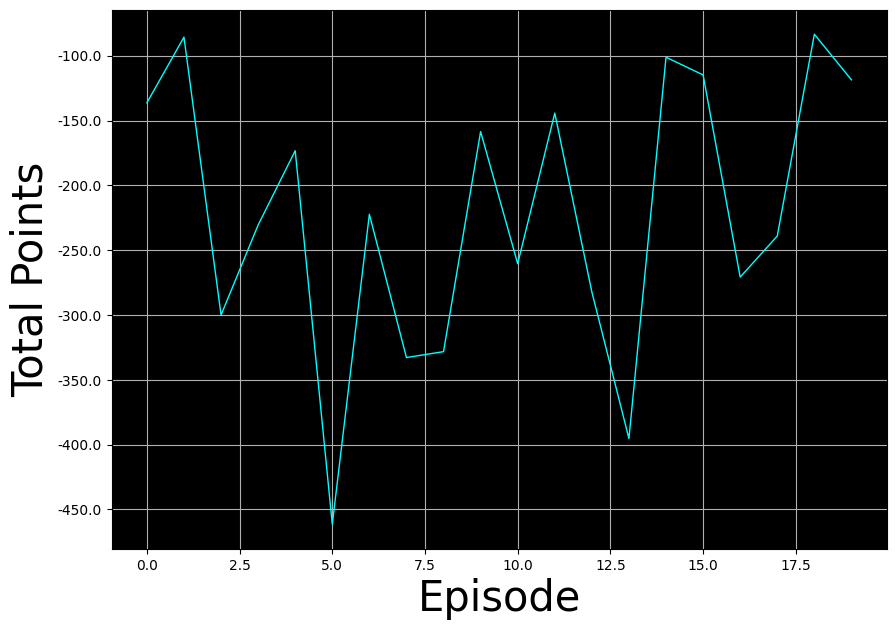

In [16]:
# Plot the point history
utils.plot_history(total_point_history)

<figure>
  <img src = "images/total_point_history.png" width = 90% style = "border: thin silver solid; padding: 0px">
      <figcaption style = "text-align: center; font-style: italic">图4. 2000s episode训练得分历史</figcaption>
</figure>

<a name="10"></a>
## 10 - 观察训练好的智能体运行情况   

既然我们已经训练好了智能体，现在就可以观察它的运行情况。我们将使用`utils.create_video`函数，借助训练好的Q网络，制作一个智能体与环境交互的视频。`utils.create_video`函数使用`imageio`库来创建视频。这个库会产生一些干扰性的警告信息，因此，为了抑制这些警告，我们运行以下代码。 

In [17]:
# Suppress warnings from imageio
import logging
logging.getLogger().setLevel(logging.ERROR)

在下面的代码单元格中，我们使用训练好的`q_network`创建一个智能体与月球着陆器环境进行交互的视频。该视频会以给定的`filename`保存到`videos`文件夹中。我们使用`utils.embed_mp4`函数将视频嵌入到Jupyter Notebook中，这样我们无需下载就能直接在此处观看。

需要注意的是，由于月球着陆器在开始时，其质心会受到一个随机的初始作用力，所以每次运行下面的代码单元格时，你看到的视频都会有所不同。如果智能体训练得当，无论其质心受到怎样的初始作用力，它都应该每次都能让月球着陆器成功降落在着陆垫上。

In [19]:
filename = "./lunar_lander.mp4"

utils.create_video(filename, env, q_network)
utils.embed_mp4("./lunar_lander_20episodes.mp4")

In [20]:
# 这是经过2000 episode训练之后的落地程序
utils.embed_mp4("./lunar_lander_2000episodes.mp4")

<a name="11"></a>
## 11 - 祝贺！
你已成功使用带经验回放的深度Q学习算法，训练出一个智能体，使其能让月球着陆器安全降落在月球表面的着陆垫上。祝贺你！

<a name="12"></a>
## 12 - 参考文献   

如果你想进一步了解深度Q学习，我们建议你查阅以下论文。   

* [通过深度强化学习实现人类水平的控制](https://storage.googleapis.com/deepmind-media/dqn/DQNNaturePaper.pdf)
  
* [深度强化学习的连续控制](https://arxiv.org/pdf/1509.02971.pdf)

  
* [使用深度强化学习玩雅达利游戏](https://www.cs.toronto.edu/~vmnih/docs/dqn.pdf)

